In [1]:
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
%matplotlib inline
import pymc as pm
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, bernoulli, lognorm, betabinom
from scipy.stats import beta as beta_dist
from scipy.special import expit as inv_logit
from scipy.special import logit ,logsumexp
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import arviz as az
import networkx as nx
import xarray as xr

import collections.abc
collections.Iterable = collections.abc.Iterable
from causalgraphicalmodels import CausalGraphicalModel
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
from matplotlib.patches import FancyArrowPatch

import warnings
warnings.filterwarnings('ignore')


%config InlineBackend.figure_format = 'retina'

plt.style.use(['seaborn-v0_8-darkgrid','seaborn-v0_8-colorblind'])

#### Code 15.1

In [305]:
def sim_pancakes():
    pancake = np.random.choice([0,1,2],1)
    sides = np.array([1, 1, 1, 0, 0, 0]).reshape(3, 2).T[:,pancake]
    return np.random.permutation(sides)

pancakes = np.array([sim_pancakes().flatten() for _ in range(10000)])
up = pancakes[:,0]
down = pancakes[:,1]

num_11_10 = np.sum(up == 1)
num_11 = np.sum((up ==1) & (down ==1))
num_11 / num_11_10

0.6630240413272402

#### Code 15.2

In [325]:
d.head()

,Location,Loc,Population,MedianAgeMarriage,Marriage,Marriage SE,Divorce,Divorce SE,WaffleHouses,South,Slaves1860,Population1860,PropSlaves1860
0,Alabama,AL,4.78,25.3,20.2,1.27,12.7,0.79,128,1,435080,964201,0.45
1,Alaska,AK,0.71,25.2,26.0,2.93,12.5,2.05,0,0,0,0,0.00
2,Arizona,AZ,6.33,25.8,20.3,0.98,10.8,0.74,18,0,0,0,0.00
3,Arkansas,AR,2.92,24.3,26.4,1.70,13.5,1.22,41,1,111115,435450,0.26
4,California,CA,37.25,26.8,19.1,0.39,8.0,0.24,0,0,0,379994,0.00


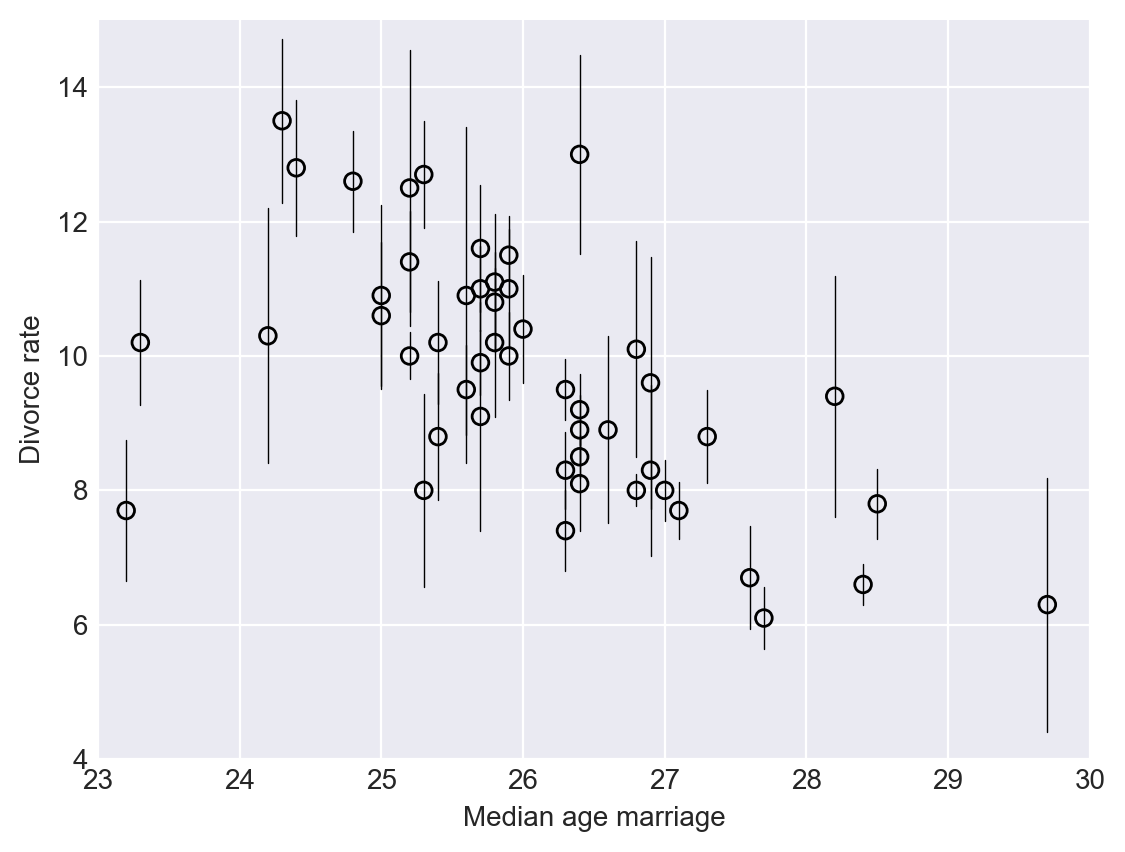

In [329]:
d = pd.read_csv('data/WaffleDivorce.csv',sep=';')

# points
plt.scatter(d.MedianAgeMarriage,d.Divorce, facecolor = 'none', edgecolor='black')
plt.ylim(4,15)
plt.xlim(23,30)
plt.xlabel('Median age marriage')
plt.ylabel('Divorce rate');

#standard errors
for i in range(d.shape[0]):
    ci = d.Divorce[i,None] + [-1,1] * d['Divorce SE'][i,None]
    x = d.MedianAgeMarriage[i]
    plt.plot([x,x], ci,color = 'black', lw = .5)

#### Code 15.3

In [376]:
D_obs = np.array(scaler.fit_transform(d[['Divorce']]).flatten())
D_sd = np.array(d['Divorce SE'] / d.Divorce.std()),
M = np.array(scaler.fit_transform(d[['Divorce']])),
A = np.array(scaler.fit_transform(d[['MedianAgeMarriage']]))
N = d.shape[0]

D_obs.shape

(50,)

In [379]:
D_obs = scaler.fit_transform(d[['Divorce']]).flatten()
D_sd = (d['Divorce SE'] / d.Divorce.std()).values
M = scaler.fit_transform(d[['Marriage']]).flatten()
A = scaler.fit_transform(d[['MedianAgeMarriage']]).flatten()
N = d.shape[0]


with pm.Model() as m15_1:
    sigma = pm.Exponential('sigma', 1)
    a = pm.Normal('a', 0,.2)
    bA = pm.Normal('bA', 0,.5)
    bM = pm.Normal('bM', 0,.5)
    mu =  a + bA * A + bM * M
    D_true = pm.Normal('D_true', mu, sigma)
    D_obs = pm.Normal('D_obs',D_true, D_sd, observed = D_obs)
    trace_m15_1 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})




Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, a, bA, bM, D_true]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [380]:
pm.summary(trace_m15_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,-0.052,0.097,-0.239,0.127,0.002,0.002,1816.0,1334.0,1.00
bA,-0.619,0.160,-0.903,-0.302,0.005,0.003,1230.0,1082.0,1.00
bM,0.042,0.170,-0.273,0.371,0.005,0.003,1344.0,1400.0,1.00
D_true[0],1.192,0.365,0.489,1.836,0.009,0.007,1674.0,1355.0,1.00
D_true[1],0.704,0.563,-0.282,1.826,0.014,0.011,1639.0,1326.0,1.00
D_true[2],0.443,0.331,-0.161,1.066,0.007,0.005,2068.0,1558.0,1.00
D_true[3],1.442,0.475,0.528,2.300,0.010,0.008,2060.0,1758.0,1.00
D_true[4],-0.910,0.121,-1.145,-0.689,0.003,0.002,1421.0,915.0,1.00
D_true[5],0.667,0.396,-0.079,1.405,0.010,0.007,1647.0,1416.0,1.00
D_true[6],-1.385,0.365,-2.066,-0.676,0.008,0.006,2290.0,980.0,1.00


#### Code 15.5

In [400]:
D_obs = scaler.fit_transform(d[['Divorce']]).flatten()
D_sd = (d['Divorce SE'] / d.Divorce.std()).values
M_obs = scaler.fit_transform(d[['Marriage']]).flatten()
M_sd = (d['Marriage SE'] / d.Marriage.std()).values
A = scaler.fit_transform(d[['MedianAgeMarriage']]).flatten()
N = d.shape[0]


with pm.Model() as m15_12:
    sigma = pm.Exponential('sigma', 1)
    a = pm.Normal('a', 0,.2)
    bA = pm.Normal('bA', 0,.5)
    bM = pm.Normal('bM', 0,.5)

    M_true = pm.Normal('M_true', 0,1, shape = N)
    M_est = pm.Normal('M_obs', M_true, M_sd, observed = M_obs)

    mu =  a + bA * A + bM * M_true
    
    D_true = pm.Normal('D_true', mu, sigma)
    D_est = pm.Normal('D_obs',D_true, D_sd, observed = D_obs)
    trace_m15_2 = pm.sample(cores = 1, idata_kwargs={'log_likelihood': True})



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, a, bA, bM, M_true, D_true]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 15.6

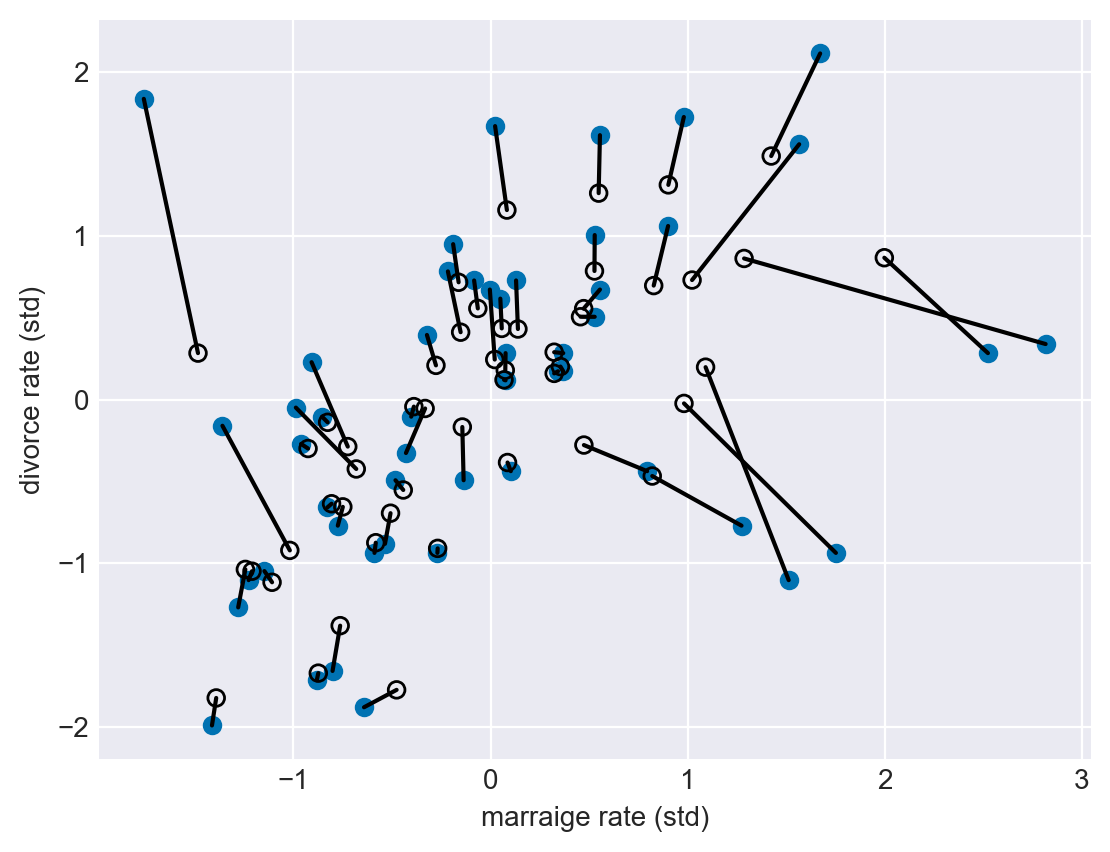

In [407]:
post = trace_m15_2.posterior.stack(sample=("chain", "draw"))
D_true = post.D_true.mean(axis = 1)
M_true = post.M_true.mean(axis = 1)

plt.scatter(M_obs, D_obs)
plt.xlabel('marraige rate (std)')
plt.ylabel('divorce rate (std)')
plt.scatter(M_true, D_true, facecolor='none', edgecolor ='black')
for i in range(d.shape[0]):
    plt.plot([M_obs[i], M_true[i]], [D_obs[i], D_true[i]], color=  'black')

#### Code 15.7

In [410]:
N = 500
A = np.random.normal(0,1,N)
M = np.random.normal(-A, 1, N)
D = np.random.normal(A, 1, N)
A_obs = np.random.normal(A, 1, N)

#### Code 15.8

In [ ]:
N = 100
S = np.random.normal(0,1,N)
H = np.random.binomial(n = 10, p = inv_logit(S), size = N)


array([ 3,  3,  2,  5,  7,  7,  0,  6,  9,  3,  7,  5,  7,  6,  1,  9,  1,
        4,  4,  1,  1,  6,  3,  4,  1,  3,  5,  8,  4,  1, 10,  3,  4,  4,
        4,  5, 10,  4,  1,  2,  2,  2,  2,  8,  8,  4,  8,  4,  6,  8,  1,
        7,  5,  5,  2,  6,  5,  2,  4,  1,  1,  6,  3,  4,  2,  5,  5,  1,
        5,  4,  6,  0,  4,  7,  7,  1,  0,  4,  7,  7,  2,  2,  2,  8,  5,
        1,  5,  8,  5,  5,  8,  3,  5,  2,  8,  3,  5,  4,  3,  2])

#### Code 15.9

In [427]:
D = np.random.binomial(n=1, p = .5, size = N)
Hm = np.where(D==1,np.nan, H)
Hm


array([nan, nan,  2.,  5.,  7.,  7.,  0.,  6.,  9., nan, nan,  5., nan,
        6.,  1.,  9., nan,  4., nan, nan, nan, nan, nan,  4.,  1.,  3.,
       nan, nan,  4.,  1., 10.,  3.,  4.,  4., nan,  5., 10.,  4.,  1.,
        2.,  2., nan,  2., nan, nan,  4., nan,  4.,  6., nan,  1.,  7.,
        5.,  5., nan,  6., nan,  2.,  4.,  1.,  1., nan,  3.,  4.,  2.,
        5., nan, nan,  5.,  4.,  6., nan, nan,  7., nan, nan, nan,  4.,
       nan,  7., nan,  2., nan, nan, nan, nan, nan, nan, nan,  5., nan,
        3., nan,  2.,  8.,  3.,  5.,  4., nan,  2.])

#### Code 15.10

In [429]:
D = np.where(S > 0, 1, 0)
Hm = np.where(D==1,np.nan, H)
Hm

array([ 3.,  3.,  2., nan, nan, nan,  0., nan, nan,  3., nan, nan, nan,
       nan,  1., nan,  1., nan, nan,  1.,  1., nan,  3.,  4.,  1.,  3.,
       nan, nan, nan,  1., nan,  3.,  4.,  4.,  4., nan, nan, nan,  1.,
        2.,  2.,  2.,  2., nan, nan,  4., nan, nan, nan, nan,  1., nan,
        5.,  5.,  2.,  6.,  5.,  2.,  4.,  1.,  1., nan,  3.,  4.,  2.,
       nan,  5.,  1., nan,  4.,  6.,  0.,  4., nan, nan,  1.,  0.,  4.,
       nan, nan,  2.,  2.,  2., nan, nan,  1.,  5., nan,  5.,  5., nan,
        3.,  5.,  2., nan,  3., nan,  4.,  3.,  2.])

#### Code 15.11

In [ ]:
np.random.seed(501)

N = 1000
X = np.random.normal(0,1,N)
S = np.random.normal(0,1,N)
H = np.random.binomial(n = 10, p = inv_logit(2 + S - 2* X), size=  N)
D = np.where(X> 1, 1, 0)
Hm = np.where(D==1, np.nan,H)
Hm

#### Code 15.12

In [448]:
dat_list = dict(
    H = H,
    S = S
)

with pm.Model() as m15_3:
    a = pm.Normal('a', 0,1)
    bS = pm.Normal('bS',0,.5)
    p = pm.math.sigmoid(a + bS * dat_list['S'])
    H_ = pm.Binomial('H',n =10, p = p, observed = dat_list['H'])
    trace_m15_3 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})
pm.summary(trace_m15_3)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a, bS]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.267,0.026,1.220,1.318,0.001,0.000,1737.0,1181.0,1.0
bS,0.709,0.027,0.658,0.761,0.001,0.001,1328.0,1454.0,1.0


In [452]:
dat_list0 = dict(
    H = H[D==0],
    S = S[D==0]
)

with pm.Model() as m15_4:
    a = pm.Normal('a', 0,1)
    bS = pm.Normal('bS',0,.5)
    p = pm.math.sigmoid(a + bS * dat_list0['S'])
    H_ = pm.Binomial('H',n =10, p = p, observed = dat_list0['H'])
    trace_m15_4 = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})
pm.summary(trace_m15_4)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [a, bS]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.878,0.035,1.811,1.941,0.001,0.001,1348.0,1276.0,1.0
bS,0.861,0.035,0.793,0.924,0.001,0.001,1180.0,1372.0,1.0


#### Code 15.14

In [ ]:
D = np.where(abs(X)<1, 1, 0)

# dat_list1 = dict(
#     H = H[D==0],
#     S = S[D==0]
# )

# with pm.Model() as m15_4_new_rule:
#     a = pm.Normal('a', 0,1)
#     bS = pm.Normal('bS',0,.5)
#     p = pm.math.sigmoid(a + bS * dat_list1['S'])
#     H_ = pm.Binomial('H',n =10, p = p, observed = dat_list1['H'])
#     trace_m15_4_new_rule = pm.sample(cores = 1, idata_kwargs={'log_likelihood':True})
# pm.summary(trace_m15_4_new_rule)

#### Code 15.15

In [455]:
N = 100
S = np.random.normal(0,1,N)
H = np.random.binomial(n= 10, p=inv_logit(S), size = N)
D = np.where(H < 5, 1, 0)
Hm = np.where(D==1, np.nan, H)
Hm

array([nan,  7.,  7.,  8.,  7., nan,  5.,  7.,  9.,  5.,  6., nan, nan,
        5., nan,  6., 10., nan, nan, nan,  7.,  7., nan,  5.,  9.,  5.,
        5., nan,  7., nan, nan,  9.,  6.,  8., nan, nan,  5., nan, nan,
        6.,  6., nan, nan,  9.,  9., 10.,  8., nan, nan,  5.,  7., nan,
        6.,  9.,  9., nan,  5.,  8.,  7.,  5.,  9., nan, nan, nan,  7.,
        5.,  9.,  8., nan, nan, nan,  6.,  6.,  8.,  5., nan,  5.,  8.,
        5., nan, nan,  7.,  7., nan,  6.,  5.,  6.,  5., nan,  8.,  6.,
        8., nan, nan, nan, nan, nan,  9.,  5., nan])

#### Code 15.16

In [ ]:
d = pd.read_csv('data/milk.csv', sep =';')
d['neocortex.prop'] = d['neocortex.perc'] / 100
d['logmass'] = np.log(d.mass)
dat_list = pd.DataFrame({
    'K' : scaler.fit_transform(d[['kcal.per.g']][:])[:,0],
    'B' : scaler.fit_transform(d[['neocortex.prop']])[:,0],
    'M' : scaler.fit_transform(d[['logmass']])[:,0]
})

#### Code 15.17

In [504]:
with pm.Model() as m15_3:
    sigma = pm.Exponential('sigma', 1)
    sigma_b = pm.Exponential('sigma_b', 1)
    a = pm.Normal('a', 0, .5)
    nu = pm.Normal('nu', 0, .5)
    dB = pm.Normal('dB', 0, .5)
    dM = pm.Normal('dM', 0, .5)

    B_ = pm.Normal("B", nu, sigma_b, observed=dat_list["B"])
    mu = a + dB * B_ + dM * dat_list['M']

    K_ = pm.Normal('K', mu, sigma, observed = dat_list['K'])

    trace_m15_3 = pm.sample(cores = 1)



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, sigma_b, a, nu, dB, dM, B_unobserved]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


#### Code 15.18

In [473]:
pm.summary(trace_m15_3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.029,0.165,-0.271,0.335,0.003,0.003,2616.0,1486.0,1.00
nu,-0.053,0.209,-0.436,0.341,0.005,0.004,2046.0,1700.0,1.00
dB,0.486,0.244,0.061,0.989,0.008,0.006,911.0,1280.0,1.00
dM,-0.534,0.210,-0.923,-0.155,0.006,0.004,1140.0,1383.0,1.00
B_unobserved[0],-0.575,0.965,-2.300,1.256,0.021,0.020,2070.0,1339.0,1.00
B_unobserved[1],-0.703,0.987,-2.529,1.248,0.023,0.018,1838.0,1341.0,1.00
B_unobserved[2],-0.718,0.982,-2.610,1.048,0.023,0.019,1960.0,1435.0,1.00
B_unobserved[3],-0.313,0.923,-2.013,1.400,0.017,0.022,2939.0,1267.0,1.00
B_unobserved[4],0.476,0.950,-1.296,2.287,0.017,0.019,3089.0,1711.0,1.00
B_unobserved[5],-0.224,0.928,-1.914,1.569,0.020,0.020,2176.0,1375.0,1.00


#### Code 15.19

In [493]:
dat_list_obs = dat_list.dropna()

with pm.Model() as m15_4:
    sigma = pm.Exponential('sigma', 1)
    sigma_b = pm.Exponential('sigma_b', 1)
    a = pm.Normal('a', 0, .5)
    nu = pm.Normal('nu', 0, .5)
    dB = pm.Normal('dB', 0, .5)
    dM = pm.Normal('dM', 0, .5)

    B_ = pm.Normal("B", nu, sigma_b, observed=dat_list_obs["B"])
    mu = a + dB * B_ + dM * dat_list_obs['M']

    K_ = pm.Normal('K', mu, sigma, observed = dat_list_obs['K'])

    trace_m15_4 = pm.sample(cores = 1)

pm.summary(trace_m15_4)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, sigma_b, a, nu, dB, dM]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.104,0.192,-0.250,0.471,0.004,0.004,2310.0,1345.0,1.0
nu,-0.002,0.217,-0.375,0.433,0.005,0.005,1871.0,1430.0,1.0
dB,0.594,0.279,0.032,1.085,0.007,0.005,1642.0,1441.0,1.0
dM,-0.630,0.258,-1.091,-0.136,0.006,0.004,1787.0,1302.0,1.0
sigma,0.890,0.190,0.596,1.229,0.005,0.004,1405.0,1357.0,1.0
sigma_b,1.057,0.188,0.728,1.397,0.005,0.004,1943.0,1102.0,1.0


#### Code 15.20

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

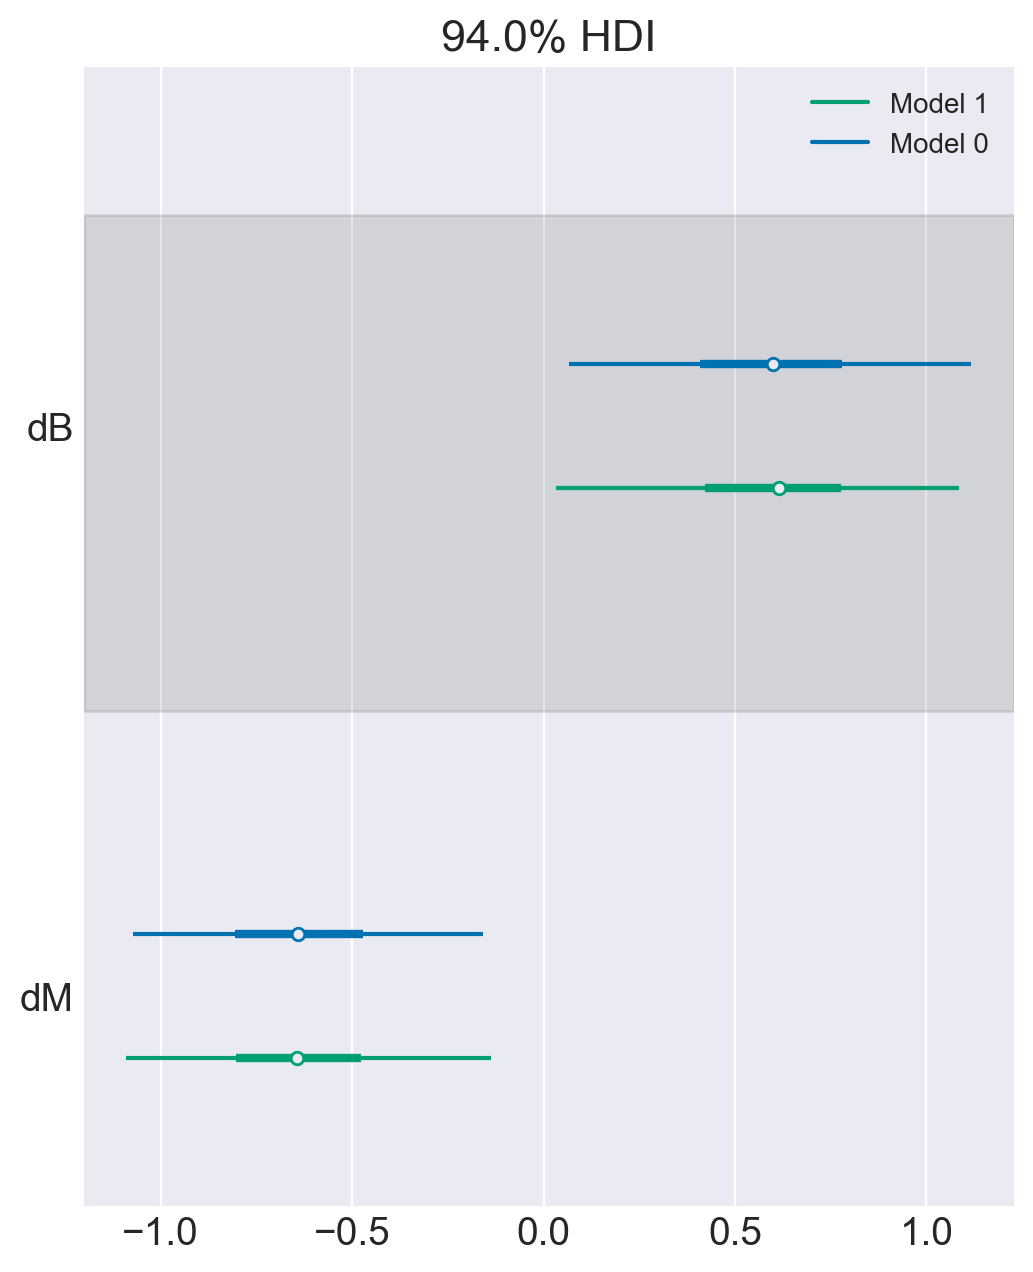

In [501]:
pm.plot_forest([trace_m15_3, trace_m15_4], combined = True, var_names = ['dB', 'dM'])

#### Code 15.21

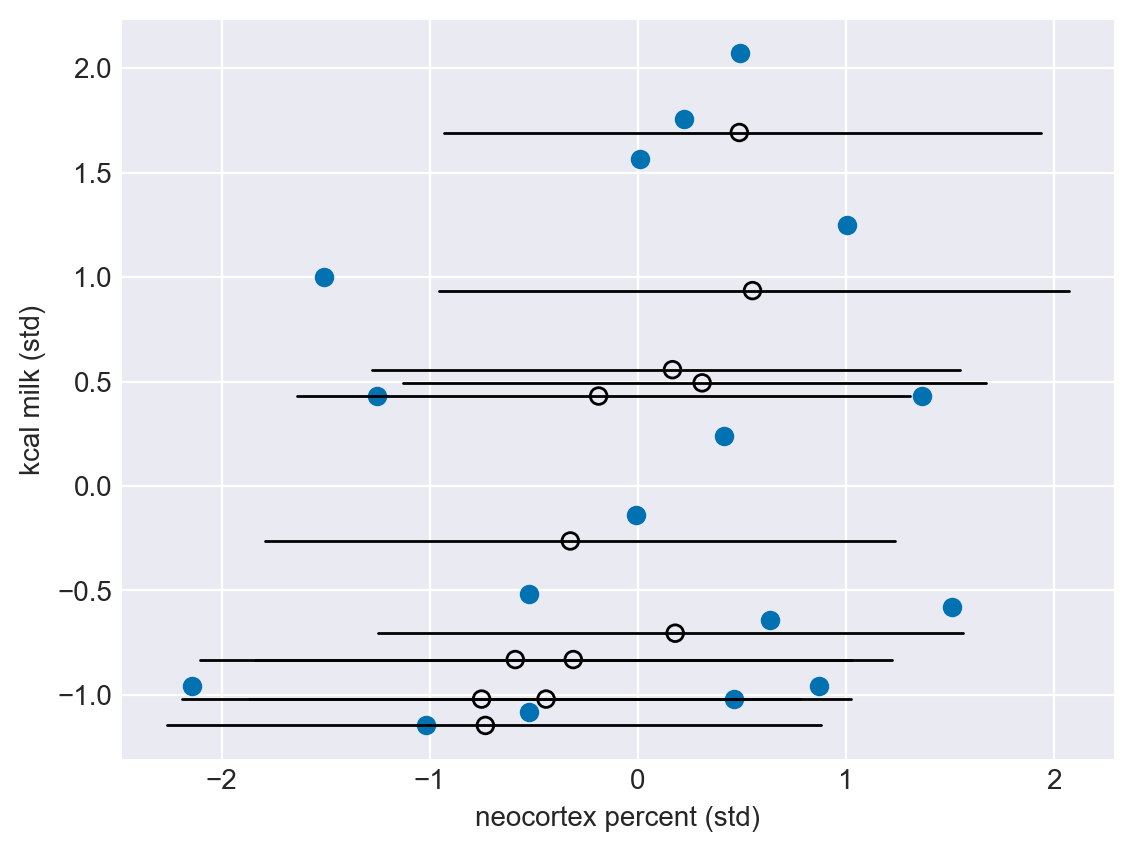

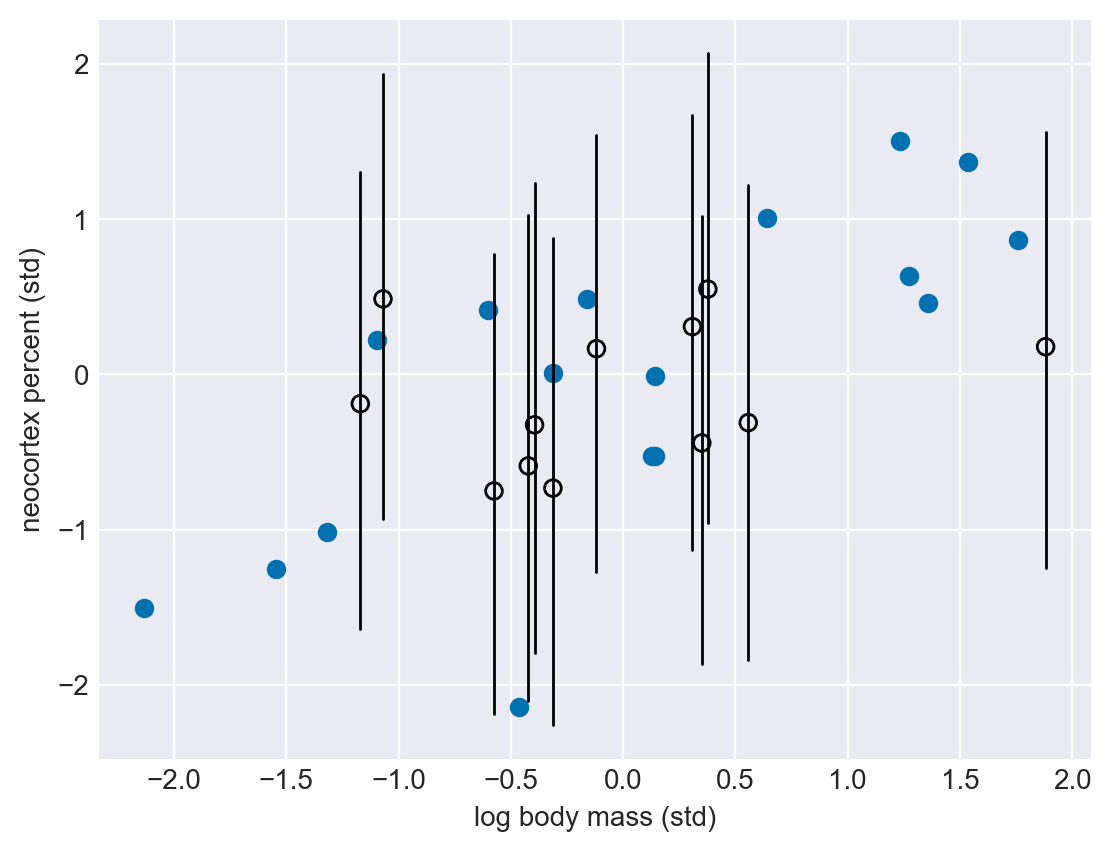

In [560]:
post = trace_m15_3.posterior.stack(sample=("chain", "draw"))


B_impute_mu = post.B_unobserved.mean(axis = 1)

B_impute_ci = np.percentile(post.B_unobserved.values,[5.5, 94.5], axis = 1)

plt.scatter(dat_list.B, dat_list.K)
plt.xlabel("neocortex percent (std)")
plt.ylabel('kcal milk (std)')
miss_idx = np.array(dat_list.B[dat_list.B.isna()].index)
Ki = dat_list.K.iloc[miss_idx].values
plt.scatter(B_impute_mu, Ki, facecolor = 'none', edgecolor = 'black')
for i in range(12):
    plt.plot(B_impute_ci[:,i], np.repeat(Ki[i],2), color = 'black', lw = 1);
plt.show()

plt.scatter(dat_list.M, dat_list.B)
plt.xlabel('log body mass (std)')
plt.ylabel('neocortex percent (std)')
Mi = Ki = dat_list.M.iloc[miss_idx].values
plt.scatter(Mi, B_impute_mu, facecolor='none', edgecolor='black')
for i in range(12):
    plt.plot(np.repeat(Mi[i],2), B_impute_ci[:,i], color = 'black', lw = 1);
plt.show()

#### Code 15.23

In [563]:
B_missidx = pd.isna(dat_list["B"])[0]

#### Code 15.24

In [566]:
Moralizing_gods = pd.read_csv('data/Moralizing_gods.csv', sep=';')
Moralizing_gods.describe().T

,count,mean,std,min,25%,50%,75%,max
year,864.0,-1339.351852,2643.227871,-9600.000000,-2900.000000,-600.000000,800.000000,1900.000000
population,864.0,4.862465,1.763263,1.408324,3.218477,4.769139,6.418871,8.530465
moralizing_gods,336.0,0.949405,0.219497,0.000000,1.000000,1.000000,1.000000,1.000000
writing,864.0,0.459491,0.498645,0.000000,0.000000,0.000000,1.000000,1.000000


#### Code 15.25

In [596]:
Moralizing_gods.pivot_table(
    index='moralizing_gods',
    values='year',
    aggfunc='count',
    dropna=False
)

,year
moralizing_gods,
0.0,17
1.0,319
NaN,528


#### Code 15.26

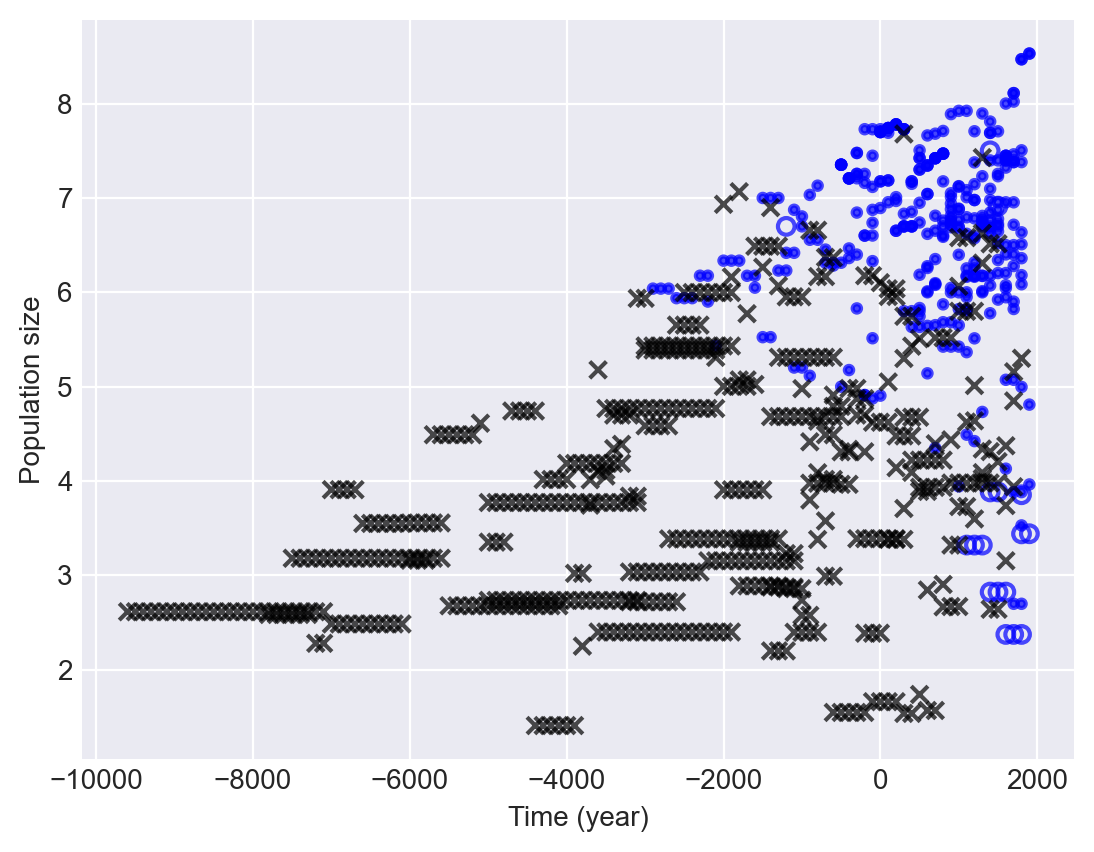

In [588]:
symbol = np.where(Moralizing_gods.moralizing_gods ==1, '.','o')
symbol = np.where(Moralizing_gods.moralizing_gods.isna(), 'x',symbol)
color = np.where(Moralizing_gods.moralizing_gods.isna(), 'black', 'blue')
for pch in ["o", ".", "x"]:
    plt.scatter(
        Moralizing_gods.year[symbol == pch],
        Moralizing_gods.population[symbol == pch],
        marker=pch,
        color=color[symbol == pch],
        facecolor="none" if pch == "o" else None,
        lw=1.5,
        alpha=0.7,
    )
plt.xlabel('Time (year)')
plt.ylabel('Population size');

In [595]:
Moralizing_gods.pivot_table(
    index='moralizing_gods',
    columns='writing',
    values='year',
    aggfunc='count',
    dropna=False
)

writing,0,1
moralizing_gods,,
0.0,16,1
1.0,9,310
NaN,442,86


#### Code 15.28

In [602]:
haw = Moralizing_gods.loc[(Moralizing_gods.polity == 'Big Island Hawaii')]
columns = ['year','writing','moralizing_gods']
haw[columns].T

,0,1,2,3,4,5,6,7,8
year,1000.0,1100.0,1200.0,1300.0,1400.0,1500.0,1600.0,1700.0,1800.0
writing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
moralizing_gods,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


#### Code 15.29

In [ ]:
np.random.seed(9)
N_houses = 100
alpha = 5
beta = -3
k = .5
r = .2

cat = np.random.binomial(1, p = k, size = N_houses)
notes = np.random.poisson(alpha + beta * cat, N_houses)
R_C = np.random.binomial(1,r, N_houses)
cat_obs = np.where(R_C==1, -9, cat)

dat = pd.DataFrame({
    'notes': notes,
    'cat': cat_obs,
    'RC': np.repeat(N_houses,len(cat_obs)),
})

,notes,cat,RC
0,4,0,100
1,0,1,100
2,8,0,100
3,5,0,100
4,5,-9,100
...,...,...,...
95,8,0,100
96,1,1,100
97,6,0,100
98,1,-9,100


#### Code 15.30

In [ ]:
with pm.Model() as m15_6:
    a = pm.Normal('a', 0, 1)
    b = pm.Normal('b', 0, 0.5)
    k = pm.Beta('k', 2, 2)

    pm.Bernoulli('cat_rc_0', p=k, observed=dat.cat[dat.RC == 0].values)

    custom_logprob = pm.math.logaddexp(
        pm.math.log(k) + pm.logp(pm.Poisson.dist(mu=pm.math.exp(a + b)), dat.notes[dat.RC == 1].values),
        pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(mu=pm.math.exp(a)), dat.notes[dat.RC == 1].values),
    )
    pm.Potential('notes_rc_1', custom_logprob)

    lambda_ = pm.math.exp(a + b * dat.cat[dat.RC == 0].values)
    pm.Poisson('notes_rc_0', mu=lambda_, observed=dat.notes[dat.RC == 0].values)

    trace_m15_6 = pm.sample(1000, chains=4, cores=1)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [a, b, k]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [ ]:
with pm.Model() as m15_7:
    a = pm.Normal('a', 0, 1)
    b = pm.Normal('b', 0, 0.5)
    k = pm.Beta('k', 2, 2)
    lambda_ = pm.math.exp(a + b * dat.cat[dat.RC == 0].values)

    notes_rc_0 = pm.Poisson('notes_rc_0', mu = lambda_, observed=dat.notes[dat.RC == 0].values)

    custom_logprob = pm.math.logaddexp(
        pm.math.log(k) + pm.logp(pm.Poisson.dist(mu=pm.math.exp(a + b)), dat.cat[dat.RC == 1].values),
        pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(mu=pm.math.exp(a)), dat.cat[dat.RC == 1].values),
    )
    notes_rc_1 = pm.Potential('notes_rc_1', custom_logprob)

    cat_rc_0 = pm.Bernoulli('cat_rc_0', p=k, observed=dat.cat[dat.RC == 0].values)

    LpC0 = pm.Deterministic("LpC0", pm.math.log(1 - k) + pm.logp(pm.Poisson.dist(pm.math.exp(a)),notes)
        )
    LpC1 = pm.Deterministic("LpC1", pm.math.log(k) + pm.logp(pm.Poisson.dist(pm.math.exp(a + b)),notes)
        )
    PrC1 = pm.Deterministic("PrC1", pm.math.exp(LpC1) / (pm.math.exp(LpC1) + pm.math.exp(LpC0)))

    trace_m15_7 = pm.sample(1000, chains=4, cores=1)

Initializing NUTS using jitter+adapt_diag...
